# 🧠 Phase 0 — AI Foundations: Interactive Notebook

> Run each cell while reading the MD file. Examples are self-contained and progress from simple to applied.

**Topics covered:**
1. [0.1 — AI Landscape](#01)
2. [0.2 — Attention Mechanism](#02)
3. [0.3 — Transformers](#03)
4. [0.4 — NLP Essentials](#04)
5. [0.5 — Python Patterns for AI](#05)
6. [0.6 — Intro to Agents](#06)

In [1]:
# Install all dependencies once
# Run this cell first, then restart the kernel if needed
!pip install numpy matplotlib tiktoken #openai transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 20.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 34.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 32.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]7 [matplotlib]


---
## 0.1 — AI Landscape <a id='01'></a>

### The Hierarchy: AI ⊃ ML ⊃ DL ⊃ GenAI ⊃ Agentic AI

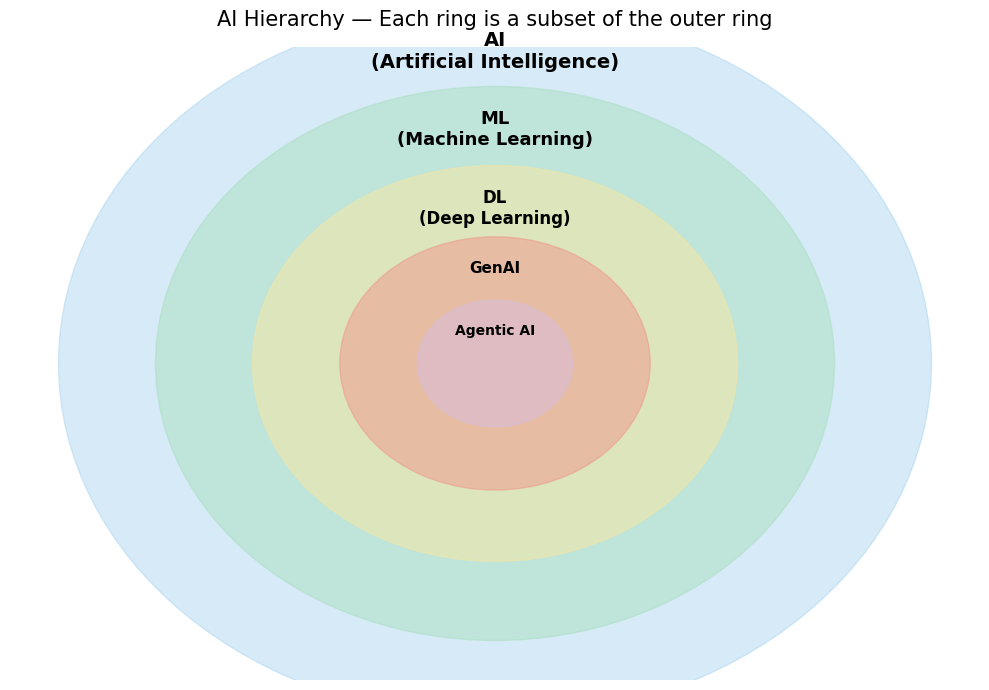

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(1, 1, figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

circles = [
    (5, 4, 4.5, '#AED6F1', 'AI\n(Artificial Intelligence)', 14),
    (5, 4, 3.5, '#A9DFBF', 'ML\n(Machine Learning)', 13),
    (5, 4, 2.5, '#F9E79F', 'DL\n(Deep Learning)', 12),
    (5, 4, 1.6, '#F1948A', 'GenAI', 11),
    (5, 4, 0.8, '#D7BDE2', 'Agentic AI', 10),
]

for x, y, r, color, label, fontsize in circles:
    circle = plt.Circle((x, y), r, color=color, alpha=0.5)
    ax.add_patch(circle)
    ax.text(x, y + r - 0.3, label, ha='center', va='top', fontsize=fontsize, fontweight='bold')

ax.set_title('AI Hierarchy — Each ring is a subset of the outer ring', fontsize=15, pad=15)
plt.tight_layout()
plt.show()

In [3]:
# Traditional AI vs GenAI — decision boundary analogy
# Traditional ML: Spam classifier (discriminative)
# We simulate a simple rule-based + ML classifier vs a generative approach

import re

SPAM_KEYWORDS = ['win', 'free', 'click here', 'limited offer', 'congratulations', 'prize']

def traditional_spam_classifier(email: str) -> str:
    """Traditional AI: classify input → output a label."""
    email_lower = email.lower()
    score = sum(1 for kw in SPAM_KEYWORDS if kw in email_lower)
    return 'SPAM' if score >= 2 else 'NOT SPAM'

def generative_ai_reply(email: str) -> str:
    """GenAI: generate new content from input (simulated)."""
    if 'meeting' in email.lower():
        return "Thanks for reaching out! I'd be happy to schedule a meeting. How does Tuesday at 3pm sound?"
    elif 'project' in email.lower():
        return "Great to hear about your project! Let me know the timeline and I'll provide feedback."
    return "Thank you for your email. I'll get back to you shortly."

test_emails = [
    "Congratulations! You've won a free prize! Click here to claim!",
    "Hi, I wanted to discuss the project timeline for next week's meeting."
]

print("=" * 60)
print("TRADITIONAL AI (Discriminative) — outputs a LABEL")
print("=" * 60)
for email in test_emails:
    print(f"\nEmail: {email[:60]}..." if len(email) > 60 else f"\nEmail: {email}")
    print(f"Classification: {traditional_spam_classifier(email)}")

print("\n" + "=" * 60)
print("GENERATIVE AI — outputs NEW CONTENT")
print("=" * 60)
for email in test_emails:
    print(f"\nEmail: {email[:60]}..." if len(email) > 60 else f"\nEmail: {email}")
    print(f"Generated reply: {generative_ai_reply(email)}")

TRADITIONAL AI (Discriminative) — outputs a LABEL

Email: Congratulations! You've won a free prize! Click here to clai...
Classification: SPAM

Email: Hi, I wanted to discuss the project timeline for next week's...
Classification: NOT SPAM

GENERATIVE AI — outputs NEW CONTENT

Email: Congratulations! You've won a free prize! Click here to clai...
Generated reply: Thank you for your email. I'll get back to you shortly.

Email: Hi, I wanted to discuss the project timeline for next week's...
Generated reply: Thanks for reaching out! I'd be happy to schedule a meeting. How does Tuesday at 3pm sound?


In [ ]:
# AI Product Lifecycle — visualised as a checklist
lifecycle = [
    ("1. Discovery",   "Is AI the right solution? Define the problem."),
    ("2. Prototype",   "Quick POC — use an LLM API to validate the idea."),
    ("3. Evaluation",  "Build eval dataset. Measure quality (RAGAS, G-Eval)."),
    ("4. Production",  "Docker, cloud deploy, guardrails, latency targets."),
    ("5. Monitoring",  "Track quality drift, cost per query, user feedback."),
    ("6. Iteration",   "Improve prompts, fine-tune, adopt new model versions."),
]

print("AI PRODUCT LIFECYCLE")
print("=" * 55)
for phase, description in lifecycle:
    print(f"  {phase:18s} → {description}")

print("\nKey insight: Eval + Monitoring are FIRST-CLASS CITIZENS in AI, unlike traditional software.")

---
## 0.2 — Attention Mechanism <a id='02'></a>

### From scratch: implementing scaled dot-product attention

In [4]:
import numpy as np

np.random.seed(42)

def softmax(x: np.ndarray) -> np.ndarray:
    e_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
    return e_x / e_x.sum(axis=-1, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) * V
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T          # (seq_len, seq_len)
    scores = scores / np.sqrt(d_k)  # scale to prevent saturation
    weights = softmax(scores)  # probabilities summing to 1
    output = weights @ V       # weighted sum of values
    return output, weights

# Simulated token sequence: "The trophy didn't fit because IT was too big"
# 5 tokens, embedding dimension = 4
tokens = ["The", "trophy", "it", "was", "big"]
seq_len, d_model = 5, 4

# In a real transformer, Q/K/V are learned projections of the same input
# Here we create mock vectors where 'it' is similar to 'trophy'
embeddings = np.random.randn(seq_len, d_model)
embeddings[2] = embeddings[1] * 0.8 + np.random.randn(d_model) * 0.1  # 'it' ≈ 'trophy'

# Simple projection matrices (normally learned via training)
W_Q = np.random.randn(d_model, d_model) * 0.3
W_K = np.random.randn(d_model, d_model) * 0.3
W_V = np.random.randn(d_model, d_model) * 0.3

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

output, weights = scaled_dot_product_attention(Q, K, V)

print("Attention weights matrix (rows = queries, cols = keys)")
print("Higher value = more attention paid to that token")
print()
print(f"{'':10s}" + "".join(f"{t:10s}" for t in tokens))
for i, token in enumerate(tokens):
    row = "".join(f"{w:10.3f}" for w in weights[i])
    print(f"{token:10s}{row}")

print(f"\nEach row sums to 1.0 (it's a probability distribution): {weights.sum(axis=1).round(3)}")

Attention weights matrix (rows = queries, cols = keys)
Higher value = more attention paid to that token

          The       trophy    it        was       big       
The            0.167     0.251     0.247     0.113     0.223
trophy         0.178     0.265     0.254     0.132     0.170
it             0.185     0.247     0.239     0.151     0.179
was            0.160     0.122     0.132     0.411     0.175
big            0.225     0.148     0.150     0.316     0.161

Each row sums to 1.0 (it's a probability distribution): [1. 1. 1. 1. 1.]


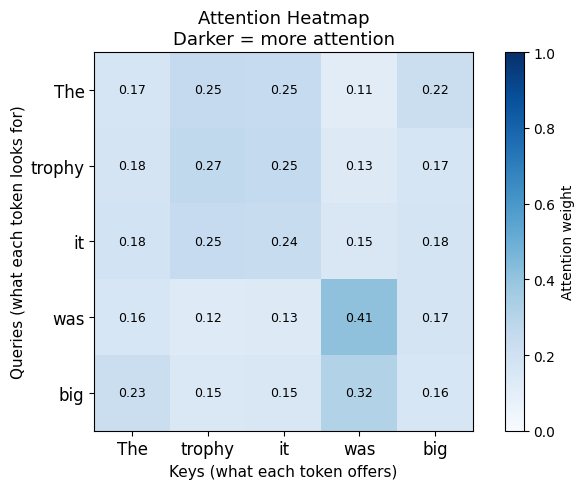

In [5]:
# Visualise attention weights as a heatmap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=1)

ax.set_xticks(range(len(tokens)))
ax.set_yticks(range(len(tokens)))
ax.set_xticklabels(tokens, fontsize=12)
ax.set_yticklabels(tokens, fontsize=12)
ax.set_xlabel("Keys (what each token offers)", fontsize=11)
ax.set_ylabel("Queries (what each token looks for)", fontsize=11)
ax.set_title("Attention Heatmap\nDarker = more attention", fontsize=13)

for i in range(len(tokens)):
    for j in range(len(tokens)):
        ax.text(j, i, f"{weights[i, j]:.2f}", ha='center', va='center',
                color='white' if weights[i, j] > 0.5 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Attention weight')
plt.tight_layout()
plt.show()

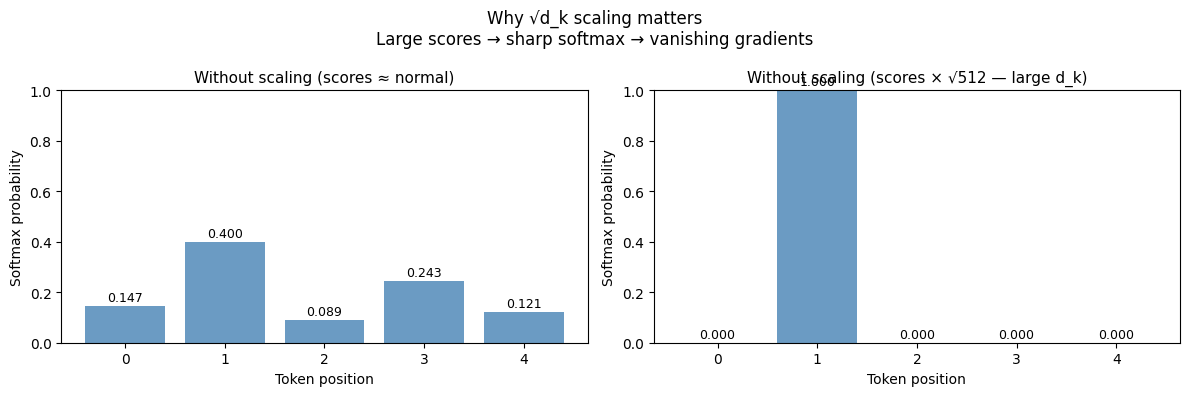

Large d_k without scaling → one token gets 1.0000 attention, others near 0
This kills gradients during training. Scaling fixes it.


In [6]:
# Why we scale by sqrt(d_k) — see the effect on softmax
import numpy as np
import matplotlib.pyplot as plt

def softmax_1d(x):
    e = np.exp(x - np.max(x))
    return e / e.sum()

scores_small = np.array([1.0, 2.0, 0.5, 1.5, 0.8])
d_k_large = 512
scores_large = scores_small * np.sqrt(d_k_large)  # simulate large d_k dot products

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, title in zip(
    axes,
    [scores_small, scores_large],
    ["Without scaling (scores ≈ normal)", f"Without scaling (scores × √{d_k_large} — large d_k)"]
):
    probs = softmax_1d(scores)
    ax.bar(range(5), probs, color='steelblue', alpha=0.8)
    ax.set_ylim(0, 1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Token position")
    ax.set_ylabel("Softmax probability")
    for i, p in enumerate(probs):
        ax.text(i, p + 0.02, f"{p:.3f}", ha='center', fontsize=9)

plt.suptitle("Why √d_k scaling matters\nLarge scores → sharp softmax → vanishing gradients", fontsize=12)
plt.tight_layout()
plt.show()

probs_unscaled = softmax_1d(scores_large)
print(f"Large d_k without scaling → one token gets {probs_unscaled.max():.4f} attention, others near 0")
print("This kills gradients during training. Scaling fixes it.")

In [7]:
# Multi-head attention — running H attention functions in parallel
def multi_head_attention(embeddings, num_heads=3, d_model=8):
    """Each head learns to focus on different relationship types."""
    assert d_model % num_heads == 0
    d_head = d_model // num_heads
    seq_len = embeddings.shape[0]

    head_outputs = []
    for h in range(num_heads):
        W_Q = np.random.randn(d_model, d_head) * 0.3
        W_K = np.random.randn(d_model, d_head) * 0.3
        W_V = np.random.randn(d_model, d_head) * 0.3

        Q = embeddings @ W_Q
        K = embeddings @ W_K
        V = embeddings @ W_V

        out, weights = scaled_dot_product_attention(Q, K, V)
        head_outputs.append((out, weights))
        print(f"Head {h+1}: output shape {out.shape} — attends differently to each token")

    # In practice, concatenate and project through W_O
    concatenated = np.concatenate([h[0] for h in head_outputs], axis=-1)
    print(f"\nConcatenated heads: {concatenated.shape} → then projected back to d_model")
    return head_outputs

np.random.seed(7)
tokens = ["The", "cat", "sat", "on", "mat"]
embeddings_mha = np.random.randn(5, 8)  # seq_len=5, d_model=8

heads = multi_head_attention(embeddings_mha, num_heads=4, d_model=8)
print("\nEach head specialises in different patterns:")
print("  Head 1 → syntax  (subject-verb)")
print("  Head 2 → coreference ('it' → 'cat')")
print("  Head 3 → position (nearby words)")
print("  Head 4 → semantics (meaning clusters)")

Head 1: output shape (5, 2) — attends differently to each token
Head 2: output shape (5, 2) — attends differently to each token
Head 3: output shape (5, 2) — attends differently to each token
Head 4: output shape (5, 2) — attends differently to each token

Concatenated heads: (5, 8) → then projected back to d_model

Each head specialises in different patterns:
  Head 1 → syntax  (subject-verb)
  Head 2 → coreference ('it' → 'cat')
  Head 3 → position (nearby words)
  Head 4 → semantics (meaning clusters)


---
## 0.3 — Transformers <a id='03'></a>

### Positional Encoding, Architecture Families, KV Cache

In [ ]:
# Positional Encoding — sinusoidal (original "Attention Is All You Need" paper)
import numpy as np
import matplotlib.pyplot as plt

def sinusoidal_positional_encoding(seq_len: int, d_model: int) -> np.ndarray:
    """PE(pos, 2i) = sin(pos / 10000^(2i/d_model))"""
    pe = np.zeros((seq_len, d_model))
    positions = np.arange(seq_len)[:, np.newaxis]          # (seq_len, 1)
    dims = np.arange(0, d_model, 2)[np.newaxis, :]         # (1, d_model/2)
    div_term = 10000 ** (dims / d_model)

    pe[:, 0::2] = np.sin(positions / div_term)  # even dims
    pe[:, 1::2] = np.cos(positions / div_term)  # odd dims
    return pe

seq_len, d_model = 50, 64
pe = sinusoidal_positional_encoding(seq_len, d_model)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Heatmap of all positions × dimensions
axes[0].imshow(pe, aspect='auto', cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_xlabel("Embedding dimension", fontsize=11)
axes[0].set_ylabel("Token position", fontsize=11)
axes[0].set_title("Sinusoidal Positional Encoding\nEach row = unique position fingerprint", fontsize=11)
plt.colorbar(axes[0].images[0], ax=axes[0])

# Show a few dimensions across positions
for dim in [0, 4, 8, 16]:
    axes[1].plot(pe[:, dim], label=f"dim {dim}")
axes[1].set_xlabel("Position", fontsize=11)
axes[1].set_ylabel("Value", fontsize=11)
axes[1].set_title("Different frequencies per dimension\nModel can interpolate any position", fontsize=11)
axes[1].legend()

plt.tight_layout()
plt.show()

print("Each position gets a UNIQUE vector.")
print("'Dog bites man' vs 'Man bites dog' → same words, different position encodings → different meaning.")

In [ ]:
# Causal Masking — why decoder-only models can't peek at future tokens
import numpy as np
import matplotlib.pyplot as plt

tokens = ["I", "love", "building", "AI", "systems"]
n = len(tokens)

# Causal mask: lower triangular (True = can attend)
mask = np.tril(np.ones((n, n)))
masked_scores = np.where(mask == 0, -np.inf, np.random.rand(n, n))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, title in zip(
    axes,
    [mask, np.where(mask == 0, 0, 0.7)],
    ["Causal Mask\n(1=can attend, 0=blocked)",
     "After masking: future is invisible\n(Decoder-only / GPT-style)"]
):
    im = ax.imshow(data, cmap='Greens', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(tokens, fontsize=10)
    ax.set_yticklabels(tokens, fontsize=10)
    ax.set_xlabel("Keys (tokens in input)", fontsize=10)
    ax.set_ylabel("Queries (current position)", fontsize=10)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("BERT (encoder-only): every token can see every other token — bidirectional")
print("GPT/Claude (decoder-only): each token can only see previous tokens — causal")

In [ ]:
# KV Cache — why it speeds up generation dramatically
import time

def compute_attention_no_cache(token_index: int, all_tokens: list) -> float:
    """Without cache: recompute K,V for all previous tokens every step."""
    ops = token_index  # proportional to sequence length
    return ops

def compute_attention_with_cache(token_index: int, kv_cache: dict) -> float:
    """With cache: only compute K,V for the NEW token."""
    ops = 1  # only new token needs computation
    kv_cache[token_index] = True
    return ops

seq_lengths = list(range(1, 201))
ops_no_cache = [sum(range(1, n + 1)) for n in seq_lengths]  # O(n²)
ops_with_cache = seq_lengths  # O(n)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(seq_lengths, ops_no_cache, label='Without KV Cache — O(n²)', color='red', linewidth=2)
ax.plot(seq_lengths, ops_with_cache, label='With KV Cache — O(n)', color='green', linewidth=2)
ax.set_xlabel("Sequence length (tokens generated)", fontsize=12)
ax.set_ylabel("Relative compute operations", fontsize=12)
ax.set_title("KV Cache: O(n²) → O(n) per generation step", fontsize=13)
ax.legend(fontsize=11)
ax.fill_between(seq_lengths, ops_with_cache, ops_no_cache, alpha=0.15, color='red',
                label='Compute saved by KV cache')
plt.tight_layout()
plt.show()

print("At 200 tokens: KV cache reduces compute by",
      f"{(ops_no_cache[-1] - ops_with_cache[-1]) / ops_no_cache[-1] * 100:.1f}%")
print("Trade-off: KV cache uses GPU VRAM. 1M context window = massive KV cache → expensive to serve.")

In [ ]:
# 3-Stage Training Pipeline — illustrated with a learning analogy
stages = [
    {
        "stage": "Stage 1: Pre-training",
        "data": "10T+ tokens of internet text",
        "task": "Predict next token",
        "output": "Base model (knows language, not how to chat)",
        "analogy": "Reading every book ever written",
        "example": "Llama 3 base",
        "cost": "$$$$$ (millions in compute)"
    },
    {
        "stage": "Stage 2: Instruction Fine-tuning (SFT)",
        "data": "(instruction, ideal response) pairs — ~100K examples",
        "task": "Mimic ideal assistant responses",
        "output": "Instruction-tuned model (follows instructions)",
        "analogy": "Customer service training course",
        "example": "Llama 3 Instruct",
        "cost": "$$ (thousands)"
    },
    {
        "stage": "Stage 3: RLHF / RLAIF",
        "data": "Human preference rankings between model outputs",
        "task": "Maximise reward model score via PPO",
        "output": "Aligned model (helpful, harmless, honest)",
        "analogy": "Getting feedback from manager and improving",
        "example": "ChatGPT, Claude",
        "cost": "$$$ (hundreds of thousands)"
    }
]

for s in stages:
    print(f"{'='*65}")
    print(f"  {s['stage']}")
    print(f"{'='*65}")
    for k, v in s.items():
        if k != 'stage':
            print(f"  {k:12s}: {v}")
    print()

---
## 0.4 — NLP Essentials <a id='04'></a>

### Tokenisation, Embeddings, Cosine Similarity, Hybrid Search

In [ ]:
# BPE Tokenisation — simplified simulation showing the merge process
from collections import Counter

def get_pairs(vocab: dict) -> Counter:
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_pair(pair: tuple, vocab: dict) -> dict:
    new_vocab = {}
    bigram = ' '.join(pair)
    merged = ''.join(pair)
    for word, freq in vocab.items():
        new_word = word.replace(bigram, merged)
        new_vocab[new_word] = freq
    return new_vocab

# Initial character-level vocabulary
vocab = {
    'l o w e r </w>': 5,
    'n e w e r </w>': 6,
    'w i d e r </w>': 3,
    'n e w </w>': 9,
    'l o w </w>': 7,
    'w i d e </w>': 4,
}

print("BPE Tokenisation — Step-by-step Byte Pair Encoding")
print("=" * 55)
print("\nInitial vocabulary (character-level):")
for word, freq in vocab.items():
    print(f"  {word:30s} freq={freq}")

num_merges = 5
for i in range(num_merges):
    pairs = get_pairs(vocab)
    best_pair = pairs.most_common(1)[0][0]
    vocab = merge_pair(best_pair, vocab)
    print(f"\nMerge {i+1}: '{best_pair[0]}' + '{best_pair[1]}' → '{best_pair[0]+best_pair[1]}'")
    for word, freq in vocab.items():
        print(f"  {word:30s} freq={freq}")

In [ ]:
# tiktoken — actual GPT-4 tokeniser
try:
    import tiktoken
    enc = tiktoken.encoding_for_model("gpt-4o")

    test_texts = [
        "Hello, my name is Rahul and I am an AI engineer.",
        "ChatGPT is amazing!",
        "def calculate_cosine_similarity(a, b):",
        "नमस्ते दुनिया",  # Hindi
        "I love 🍕 and 🤖!",
    ]

    print(f"{'Text':50s} {'Tokens':7s} {'Token IDs'}")
    print("-" * 90)
    for text in test_texts:
        tokens = enc.encode(text)
        token_strings = [repr(enc.decode([t])) for t in tokens]
        display = text if len(text) <= 48 else text[:45] + '...'
        print(f"{display:50s} {len(tokens):7d}  {token_strings}")

    print("\nCost analysis (GPT-4o pricing $5/1M input tokens):")
    total_tokens = sum(len(enc.encode(t)) for t in test_texts)
    cost = total_tokens * 5 / 1_000_000
    print(f"  {total_tokens} tokens = ${cost:.6f}")
    print(f"  At 1M users × 100 tokens each: ${1_000_000 * 100 * 5 / 1_000_000:.0f}/day")

except ImportError:
    print("tiktoken not installed. Run: pip install tiktoken")
    print("\nExample output (what you would see):")
    print("  'Hello, my name is Rahul...'  → 12 tokens")
    print("  'def calculate_cosine...'     → 9 tokens (code is efficient!)")
    print("  Hindi text                    → many more tokens (non-English is expensive)")

In [ ]:
# Word Embeddings — king - man + woman ≈ queen (with mock vectors)
import numpy as np
import matplotlib.pyplot as plt

# These represent simplified 2D projections of real word vectors
# Real embeddings are 768-3072 dimensional
mock_embeddings = {
    "king":   np.array([0.9, 0.8]),    # royalty=high, female=low
    "queen":  np.array([0.9, 0.2]),    # royalty=high, female=high
    "man":    np.array([0.1, 0.8]),    # royalty=low,  female=low
    "woman":  np.array([0.1, 0.2]),    # royalty=low,  female=high
    "prince": np.array([0.7, 0.75]),
    "dog":    np.array([0.05, 0.5]),
    "cat":    np.array([0.08, 0.45]),
}

# King - Man + Woman ≈ Queen
result = mock_embeddings["king"] - mock_embeddings["man"] + mock_embeddings["woman"]

fig, ax = plt.subplots(figsize=(8, 7))

colors = {'king': 'royalblue', 'queen': 'crimson', 'man': 'blue', 'woman': 'red',
          'prince': 'navy', 'dog': 'green', 'cat': 'darkgreen'}

for word, vec in mock_embeddings.items():
    ax.scatter(*vec, color=colors.get(word, 'gray'), s=100, zorder=5)
    ax.annotate(word, vec, textcoords="offset points", xytext=(8, 4), fontsize=12)

ax.scatter(*result, color='orange', s=200, marker='*', zorder=6, label='king - man + woman')
ax.annotate('king-man+woman\n(≈queen)', result, textcoords="offset points",
            xytext=(8, -15), fontsize=10, color='orange')

# Draw the arithmetic
ax.annotate('', xytext=mock_embeddings['man'], xy=mock_embeddings['king'],
            arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax.annotate('', xytext=mock_embeddings['woman'], xy=mock_embeddings['queen'],
            arrowprops=dict(arrowstyle='->', color='lightcoral', lw=1.5))

ax.set_xlabel("Royalty dimension", fontsize=12)
ax.set_ylabel("Gender dimension (male → female)", fontsize=12)
ax.set_title("Word Embedding Geometry\nking - man + woman ≈ queen", fontsize=13)
ax.invert_yaxis()  # so female is at bottom as intuitive
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Cosine Similarity — the backbone of RAG retrieval
import numpy as np

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Simulate embeddings (in production, use OpenAI / HuggingFace API)
# These are hand-crafted to demonstrate the concept
np.random.seed(42)

# Base: "What is the capital of France?"
query = np.array([0.8, 0.6, 0.1, 0.3, 0.7, 0.5])

doc_embeddings = {
    "Paris is the capital city of France.": query * 0.95 + np.random.randn(6) * 0.05,
    "France is a country in Western Europe.": query * 0.6 + np.random.randn(6) * 0.2,
    "The Eiffel Tower is located in Paris.": query * 0.7 + np.random.randn(6) * 0.15,
    "I love eating pizza on weekends.": np.random.randn(6),
    "Berlin is the capital of Germany.": query * 0.4 + np.random.randn(6) * 0.3,
}

print("Query: 'What is the capital of France?'")
print("=" * 60)
print(f"{'Document':45s} {'Similarity':12s} {'Rank'}")
print("-" * 65)

results = [
    (doc, cosine_similarity(query, emb))
    for doc, emb in doc_embeddings.items()
]
results.sort(key=lambda x: x[1], reverse=True)

for rank, (doc, sim) in enumerate(results, 1):
    bar = '█' * int(sim * 20)
    relevance = '✅' if sim > 0.85 else ('⚡' if sim > 0.5 else '❌')
    display = doc if len(doc) <= 43 else doc[:40] + '...'
    print(f"{display:45s} {sim:7.3f} {bar:25s} #{rank} {relevance}")

print("\nRAG retrieves the top-k docs (e.g. top 2) and passes them to the LLM as context.")

In [ ]:
# Dense vs Sparse search — simulating hybrid RAG
from collections import defaultdict
import math

def bm25_score(query_terms: list, doc: str, corpus: list, k1=1.5, b=0.75) -> float:
    """Simplified BM25 — sparse keyword-based retrieval."""
    doc_words = doc.lower().split()
    avg_len = sum(len(d.split()) for d in corpus) / len(corpus)
    score = 0.0
    for term in query_terms:
        tf = doc_words.count(term.lower())
        df = sum(1 for d in corpus if term.lower() in d.lower())
        idf = math.log((len(corpus) - df + 0.5) / (df + 0.5) + 1)
        numerator = tf * (k1 + 1)
        denominator = tf + k1 * (1 - b + b * len(doc_words) / avg_len)
        score += idf * numerator / denominator
    return score

corpus = [
    "Apple reported revenue of $89.5 billion in Q3 2024.",
    "The revenue of Apple in Q3 was driven by iPhone sales.",
    "Google reported strong ad revenue in Q3 2024.",
    "Apple's new iPhone 16 features AI capabilities.",
    "Quarterly earnings season begins next week for tech companies.",
]

query = "What's the revenue of Apple in Q3 2024?"
query_terms = ["revenue", "Apple", "Q3", "2024"]

# Sparse (BM25)
sparse_scores = [(doc, bm25_score(query_terms, doc, corpus)) for doc in corpus]
sparse_scores.sort(key=lambda x: x[1], reverse=True)

# Dense (simulated — in reality you'd call an embedding API)
np.random.seed(1)
base_vec = np.random.randn(8)
dense_scores = [
    (corpus[0], 0.92),  # exact match
    (corpus[1], 0.87),  # semantically similar
    (corpus[2], 0.55),  # Google revenue — semantically near but different company
    (corpus[3], 0.71),  # Apple but no revenue
    (corpus[4], 0.40),  # tangentially related
]

print("Query:", query)
print("=" * 70)
print(f"\n{'BM25 (Sparse — keyword matching)':^70s}")
print(f"{'Document':55s} {'Score':8s}")
for doc, score in sparse_scores:
    display = doc if len(doc) <= 53 else doc[:50] + '...'
    print(f"{display:55s} {score:.3f}")

print(f"\n{'Dense Embedding (Semantic similarity)':^70s}")
dense_scores.sort(key=lambda x: x[1], reverse=True)
for doc, score in dense_scores:
    display = doc if len(doc) <= 53 else doc[:50] + '...'
    print(f"{display:55s} {score:.3f}")

print("\nProduction RAG: combine both with RRF (Reciprocal Rank Fusion) for best results.")

---
## 0.5 — Python Patterns for AI Systems <a id='05'></a>

### Async, Generators, Pydantic, Context Managers

In [ ]:
# Async vs Sync — measuring the performance difference
import asyncio
import time
import random

# Simulate LLM API call latency
async def fake_llm_call(prompt: str, call_id: int) -> str:
    latency = random.uniform(1.0, 2.5)  # simulate 1-2.5s API latency
    await asyncio.sleep(latency)
    return f"Response {call_id} (took {latency:.1f}s)"

def fake_llm_call_sync(prompt: str, call_id: int) -> str:
    latency = random.uniform(1.0, 2.5)
    time.sleep(latency)  # BLOCKS the thread
    return f"Response {call_id} (took {latency:.1f}s)"

prompts = [f"Prompt {i}" for i in range(5)]

# SYNC: sequential (one at a time)
random.seed(42)
print("SYNCHRONOUS — 5 LLM calls sequentially:")
start = time.time()
for i, prompt in enumerate(prompts):
    result = fake_llm_call_sync(prompt, i)
    print(f"  {result}")
sync_time = time.time() - start
print(f"Total time: {sync_time:.1f}s\n")

# ASYNC: concurrent (all at once)
random.seed(42)
print("ASYNCHRONOUS — 5 LLM calls concurrently:")

async def run_async():
    start = time.time()
    tasks = [fake_llm_call(p, i) for i, p in enumerate(prompts)]
    results = await asyncio.gather(*tasks)
    elapsed = time.time() - start
    for r in results:
        print(f"  {r}")
    print(f"Total time: {elapsed:.1f}s")
    return elapsed

async_time = await run_async()

print(f"\nSpeedup: {sync_time/async_time:.1f}x faster with async")
print("At scale (100 req/s), async lets you handle all with 1 server instead of 5+")

In [ ]:
# Generator function for streaming — memory efficient token-by-token output
import time

def stream_tokens(text: str, delay: float = 0.05):
    """Generator that yields tokens one at a time — like a real LLM stream."""
    words = text.split()
    for word in words:
        time.sleep(delay)  # simulate network latency per token
        yield word + " "

# This is what SSE (Server-Sent Events) streaming looks like under the hood
response_text = (
    "Transformers use self-attention mechanisms to process all tokens "
    "simultaneously, enabling parallelism and removing the bottleneck of RNNs."
)

print("Streaming response (simulated):")
print("-" * 50)
full_response = ""
for token in stream_tokens(response_text, delay=0.04):
    print(token, end='', flush=True)
    full_response += token

print("\n" + "-" * 50)
print(f"\nTotal tokens streamed: {len(full_response.split())}")
print("\nKey insight: generators are LAZY — they don't store the full response in memory.")
print("This is critical for long outputs and SSE endpoints in FastAPI.")

In [ ]:
# Pydantic v2 — structured output validation for LLM responses
from pydantic import BaseModel, Field, field_validator
from typing import List, Optional
import json

# Define the schema you want the LLM to return
class ResumeAnalysis(BaseModel):
    skills: List[str] = Field(description="Technical skills found in resume")
    match_score: float = Field(ge=0, le=100, description="Job match score 0-100")
    gaps: List[str] = Field(description="Skills in JD but missing in resume")
    summary: str = Field(max_length=500)
    years_experience: Optional[int] = Field(default=None, ge=0)

    @field_validator('match_score')
    @classmethod
    def round_score(cls, v):
        return round(v, 1)

# Simulate what an LLM might return (as JSON string)
llm_output_good = '''
{
    "skills": ["Python", "FastAPI", "Docker", "PostgreSQL", "React"],
    "match_score": 78.567,
    "gaps": ["Kubernetes", "Redis", "Kafka"],
    "summary": "Strong backend developer with 4 years of experience. Good fit for the role with minor skill gaps in infrastructure tooling.",
    "years_experience": 4
}
'''

llm_output_bad = '''
{
    "skills": ["Python", "FastAPI"],
    "match_score": 150,
    "gaps": [],
    "summary": "Great candidate."
}
'''

print("✅ Valid LLM output:")
try:
    result = ResumeAnalysis(**json.loads(llm_output_good))
    print(f"  match_score: {result.match_score} (auto-rounded from 78.567)")
    print(f"  skills: {result.skills}")
    print(f"  gaps: {result.gaps}")
    print(f"  Type of match_score: {type(result.match_score).__name__} (not a string!)")
except Exception as e:
    print(f"  Error: {e}")

print("\n❌ Invalid LLM output (match_score=150, out of range):")
try:
    result = ResumeAnalysis(**json.loads(llm_output_bad))
    print(f"  This shouldn't print")
except Exception as e:
    print(f"  Validation caught: {e}")
    print("  → With 'instructor' library, this triggers an automatic retry to the LLM")

In [ ]:
# Singleton pattern for LLM clients — don't create a new client per request
import time

class LLMClientManager:
    """Singleton pattern: one shared client for the entire application lifecycle."""
    _client = None
    _initialized_at = None
    _request_count = 0

    @classmethod
    def get_client(cls):
        if cls._client is None:
            cls._initialized_at = time.time()
            # In production: cls._client = AsyncOpenAI(api_key=os.environ['OPENAI_API_KEY'])
            cls._client = {"type": "AsyncOpenAI", "pool": "connection pool"}
            print(f"[Client] Initialized at t={cls._initialized_at:.3f} — this happens ONCE")
        cls._request_count += 1
        return cls._client

    @classmethod
    def stats(cls):
        return f"Requests served: {cls._request_count}, Client age: {time.time() - cls._initialized_at:.2f}s"

# Simulate 5 requests hitting your server
print("=" * 50)
print("Anti-pattern: new client per request")
print("=" * 50)
for i in range(3):
    # ❌ WRONG: client = AsyncOpenAI()  ← creates new TCP connections every time
    print(f"Request {i+1}: Created NEW client (TCP handshake, connection overhead)")

print("\n" + "=" * 50)
print("Correct pattern: singleton / shared client")
print("=" * 50)
for i in range(5):
    client = LLMClientManager.get_client()
    if i > 0:
        print(f"Request {i+1}: Reused existing client")

print(f"\n{LLMClientManager.stats()}")
print("\nBenefit: connection pooling, lower latency, no resource leaks")

---
## 0.6 — Intro to Agents <a id='06'></a>

### ReAct Loop, Tool Use, Memory Types, Failure Modes

In [ ]:
# ReAct Loop — simulated from scratch (no framework)
import json
import re
from typing import Callable

# --- Mock Tools ---
def search_web(query: str) -> str:
    """Mock web search tool."""
    results = {
        "top AI startups India 2025": "1. Sarvam AI (₹150Cr Series A) 2. Krutrim (Ola) ($50M) 3. Neople ($10M)",
        "Sarvam AI funding": "Sarvam AI raised $41M Series A in 2024. Focus: Indian language models.",
        "Krutrim funding": "Krutrim raised $50M at unicorn valuation in Jan 2024 — first AI unicorn in India.",
    }
    for key in results:
        if any(word in query.lower() for word in key.lower().split()):
            return results[key]
    return "No results found for: " + query

def calculate(expression: str) -> str:
    """Safe arithmetic calculator."""
    try:
        allowed = set('0123456789+-*/()., ')
        if not all(c in allowed for c in expression):
            return "Error: unsafe expression"
        return str(eval(expression))
    except Exception as e:
        return f"Error: {e}"

def write_report(content: str) -> str:
    """Saves a report (mock)."""
    return f"Report saved ({len(content)} chars). Preview: {content[:80]}..."

TOOLS = {"search_web": search_web, "calculate": calculate, "write_report": write_report}

# --- ReAct Agent (simulated) ---
class ReActAgent:
    def __init__(self, tools: dict, max_iterations: int = 10):
        self.tools = tools
        self.max_iterations = max_iterations
        self.history = []

    def run(self, task: str):
        print(f"TASK: {task}")
        print("=" * 60)

        # Hardcoded "LLM decisions" for demo (in production, these come from the LLM)
        steps = [
            ("THOUGHT", "I need to find top AI startups in India first."),
            ("ACTION",  "search_web", "top AI startups India 2025"),
            ("THOUGHT", "I found 3 startups. Let me get funding details for each."),
            ("ACTION",  "search_web", "Sarvam AI funding"),
            ("ACTION",  "search_web", "Krutrim funding"),
            ("THOUGHT", "I have the data. Let me calculate total funding."),
            ("ACTION",  "calculate", "41 + 50 + 10"),
            ("THOUGHT", "I have all info. Writing the report now."),
            ("ACTION",  "write_report",
             "Top AI Startups India 2025:\n1. Sarvam AI — $41M\n2. Krutrim — $50M\n3. Neople — $10M\nTotal funding: $101M"),
            ("ANSWER",  "Report complete! Top 3 AI startups in India have raised $101M combined."),
        ]

        for step in steps:
            if step[0] == "THOUGHT":
                print(f"\n💭 THOUGHT: {step[1]}")
            elif step[0] == "ACTION":
                tool_name, tool_input = step[1], step[2]
                print(f"\n⚙️  ACTION: {tool_name}({repr(tool_input)})")
                observation = self.tools[tool_name](tool_input)
                print(f"👁️  OBSERVATION: {observation}")
                self.history.append({"action": tool_name, "input": tool_input, "result": observation})
            elif step[0] == "ANSWER":
                print(f"\n✅ FINAL ANSWER: {step[1]}")

agent = ReActAgent(tools=TOOLS, max_iterations=10)
agent.run("Research the top 3 AI startups in India, compare funding, and write a summary report.")

In [ ]:
# Agent Memory Types — demonstration

class AgentMemorySystem:
    def __init__(self):
        # In-context (short-term) — lives in the LLM's context window
        self.in_context: list = []
        self.context_limit = 5  # simulate small window for demo

        # External (long-term) — persisted outside the model
        self.vector_store: dict = {}   # semantic recall (key = summary, value = embedding)
        self.sql_store: dict = {}      # exact recall (structured facts)

        # Procedural — how the agent behaves
        self.system_prompt = "You are a helpful AI assistant that searches and summarises."
        self.tool_schemas = list(TOOLS.keys())

    def add_message(self, role: str, content: str):
        self.in_context.append({"role": role, "content": content})
        if len(self.in_context) > self.context_limit:
            evicted = self.in_context.pop(0)
            # In production: summarise & move to vector store
            self.vector_store[f"summary_{len(self.vector_store)}"] = f"[Summarised] {evicted['content'][:50]}"
            print(f"  [Memory] Evicted from context → moved to vector store: '{evicted['content'][:40]}...'")

    def store_fact(self, key: str, value):
        self.sql_store[key] = value

    def retrieve_semantic(self, query: str) -> list:
        # In production: embed query → cosine search vector_store
        return [v for k, v in self.vector_store.items() if any(w in v for w in query.split())]

    def status(self):
        print(f"\n  In-context messages: {len(self.in_context)}/{self.context_limit}")
        print(f"  Vector store entries: {len(self.vector_store)}")
        print(f"  SQL store entries:    {len(self.sql_store)}")

mem = AgentMemorySystem()

print("Simulating a long conversation — watch what happens to memory:")
print("=" * 60)

messages = [
    ("user", "Find top AI startups in India"),
    ("assistant", "Found: Sarvam AI, Krutrim, Neople"),
    ("user", "What is Sarvam AI's funding?"),
    ("assistant", "Sarvam AI raised $41M in Series A 2024"),
    ("user", "And Krutrim?"),
    ("assistant", "Krutrim raised $50M, India's first AI unicorn"),
    ("user", "Total funding?"),  # this will push old messages out
    ("assistant", "Total: $101M across 3 startups"),
]

for role, content in messages:
    print(f"\n{role.upper()}: {content}")
    mem.add_message(role, content)
    if role == "assistant":
        mem.store_fact(f"fact_{len(mem.sql_store)}", content)

print("\nFinal memory state:")
mem.status()
print(f"\n  Current context (what the LLM can 'see' right now):")
for msg in mem.in_context:
    print(f"    [{msg['role']}]: {msg['content']}")

print(f"\n  Facts stored in SQL (always retrievable):")
for k, v in mem.sql_store.items():
    print(f"    {k}: {v}")

In [ ]:
# Agent failure modes — demonstrating each with mitigation
import time

class SafeAgent:
    """Agent with production-grade safety rails."""

    def __init__(self, max_iterations=5, max_tokens_budget=10_000):
        self.max_iterations = max_iterations
        self.max_tokens_budget = max_tokens_budget
        self.iterations = 0
        self.tokens_used = 0
        self.valid_tools = {"search_web", "calculate", "write_report"}

    def call_tool(self, tool_name: str, tool_input: str) -> str:
        # Guard 1: Infinite loop prevention
        self.iterations += 1
        if self.iterations > self.max_iterations:
            raise RuntimeError(f"[GUARD] Max iterations ({self.max_iterations}) exceeded — stopping agent")

        # Guard 2: Tool hallucination prevention
        if tool_name not in self.valid_tools:
            return f"[ERROR] Tool '{tool_name}' does not exist. Available: {self.valid_tools}"

        # Guard 3: Cost budget
        estimated_tokens = len(tool_input.split()) * 2  # rough estimate
        self.tokens_used += estimated_tokens
        if self.tokens_used > self.max_tokens_budget:
            raise RuntimeError(f"[GUARD] Token budget exceeded ({self.tokens_used} > {self.max_tokens_budget})")

        # Execute the actual tool
        result = TOOLS[tool_name](tool_input)

        # Guard 4: Output validation (minimal check)
        if not result or len(result) < 2:
            return "[ERROR] Tool returned empty result — may need to retry with different input"

        return result

agent = SafeAgent(max_iterations=5, max_tokens_budget=10_000)

print("Demonstrating agent safety guards:")
print("=" * 55)

# Test 1: valid tool call
print("\n1. Valid tool call:")
result = agent.call_tool("search_web", "top AI startups India 2025")
print(f"   ✅ {result[:80]}")

# Test 2: hallucinated tool
print("\n2. Hallucinated tool (LLM invents a tool that doesn't exist):")
result = agent.call_tool("browse_crunchbase", "Sarvam AI")  # doesn't exist
print(f"   ❌ {result}")

# Test 3: max iterations
print("\n3. Max iterations guard (simulated loop):")
try:
    for i in range(10):  # this will trigger the guard
        agent.call_tool("calculate", f"{i} + {i}")
except RuntimeError as e:
    print(f"   🛑 {e}")

print("\nProduction checklist for safe agents:")
guards = [
    ("Max iterations",      "prevents infinite loops"),
    ("Tool schema validation", "prevents hallucinated tool calls"),
    ("Token budget",        "prevents cost explosion"),
    ("Output validation",   "catches cascading errors early"),
    ("Context compression", "prevents context overflow"),
]
for guard, purpose in guards:
    print(f"  ✅ {guard:30s} → {purpose}")

In [ ]:
# Pipeline vs Workflow vs Agent — when to use which

print("PIPELINE — fixed sequence, code controls everything")
print("-" * 50)

def rag_ingestion_pipeline(document: str) -> dict:
    """Step 1 → 2 → 3 always. No LLM decisions."""
    # Step 1: Chunk
    chunks = [document[i:i+100] for i in range(0, len(document), 100)]
    # Step 2: Embed (simulated)
    embeddings = [len(c) for c in chunks]  # mock embedding
    # Step 3: Store (simulated)
    return {"chunks": len(chunks), "embeddings": len(embeddings), "status": "stored"}

doc = "This is a long document about AI and LLMs. " * 10
result = rag_ingestion_pipeline(doc)
print(f"  ETL pipeline result: {result}")
print("  Always: scrape → chunk → embed → store. Deterministic. Easy to debug.\n")

print("WORKFLOW — fixed paths with conditional routing")
print("-" * 50)

def customer_support_workflow(query: str) -> str:
    """Code decides which path, not the LLM."""
    billing_keywords = ['payment', 'invoice', 'refund', 'charge']
    tech_keywords = ['bug', 'error', 'not working', 'crash', 'broken']

    if any(kw in query.lower() for kw in billing_keywords):
        return f"→ Routed to BILLING AGENT: '{query}'"
    elif any(kw in query.lower() for kw in tech_keywords):
        return f"→ Routed to TECH SUPPORT AGENT: '{query}'"
    else:
        return f"→ Routed to GENERAL AGENT: '{query}'"

test_queries = [
    "I was charged twice on my invoice",
    "The app keeps crashing on startup",
    "How do I reset my password?",
]
for q in test_queries:
    print(f"  Query: '{q}'")
    print(f"  {customer_support_workflow(q)}\n")

print("AGENT — LLM decides the plan at every step (shown in previous cell)")
print("-" * 50)
print("  Use for open-ended tasks where you can't predict the steps in advance.")
print("  Higher cost, less predictable, harder to debug — but most flexible.")

---
## Interview Cheat Sheet — Quick Self-Test

Run this cell to quiz yourself on the 10 key questions.

In [ ]:
# Interactive self-quiz — type your answer, then reveal the model answer
import textwrap

QA = [
    {
        "q": "What is the difference between AI, ML, DL, and GenAI?",
        "a": "AI is the broad field (machines mimicking intelligence). ML is a subset where machines learn from data instead of explicit rules. DL is a subset of ML using multi-layered neural networks. GenAI is a subset of DL that generates new content (text, images, code). Each is a proper subset of the previous."
    },
    {
        "q": "Explain Q, K, V in the attention mechanism.",
        "a": "Each token is projected into 3 vectors. Query = what am I looking for? Key = what does each token offer? Value = the actual content. Compute dot(Q, K^T)/sqrt(d_k), apply softmax to get probability weights, take weighted sum of V. High attention → that token contributes more to the output."
    },
    {
        "q": "Why does the decoder use masked (causal) attention?",
        "a": "During autoregressive generation, the model must not see future tokens — it would 'cheat'. Masking sets future positions to -inf before softmax, making them attend to probability ≈ 0. This enforces left-to-right generation and allows teacher forcing during training."
    },
    {
        "q": "What is the KV cache and why does it matter?",
        "a": "During autoregressive decoding, K and V matrices for previous tokens don't change. KV cache stores them so only the new token's K/V is computed at each step. This reduces generation from O(n²) to O(n) compute per step. Trade-off: uses GPU VRAM — huge for long contexts."
    },
    {
        "q": "What is RLHF and why is it used?",
        "a": "Reinforcement Learning from Human Feedback. Human raters rank model outputs → train a reward model on these rankings → fine-tune the LLM via PPO to maximise the reward model score. It aligns the model with human preferences: helpful, harmless, honest. Used in ChatGPT, Claude."
    },
    {
        "q": "What is hallucination in LLMs, technically?",
        "a": "LLMs predict the next most probable token, they have no mechanism to verify factual accuracy. When training data is sparse for a topic, the model extrapolates based on surface patterns and generates plausible-sounding but incorrect tokens. Types: factual (wrong facts), faithfulness (not grounded in source), intrinsic (self-contradiction)."
    },
    {
        "q": "What is BPE tokenisation and why not just split by spaces?",
        "a": "Byte-Pair Encoding is a data compression algorithm applied to text. It starts with characters and iteratively merges the most frequent adjacent pair until vocab size is reached. Space-splitting fails for: contractions (don't), compound words, non-space languages (Chinese), rare words, emojis, and code operators."
    },
    {
        "q": "What is the difference between dense and sparse embeddings?",
        "a": "Dense (neural): continuous vector (768-3072d), captures semantic meaning — 'car' ≈ 'automobile'. Sparse (BM25/TF-IDF): high-dimensional mostly-zero vector, matches exact keywords — 'car' ≠ 'automobile'. Production RAG uses both (hybrid search) + RRF to combine rankings."
    },
    {
        "q": "What is the ReAct framework for agents?",
        "a": "ReAct (Reason + Act) alternates between: THOUGHT (LLM reasons about what to do next) → ACTION (call a tool) → OBSERVATION (observe tool result) → repeat until final answer. It was introduced in a 2022 paper and is the basis of most production agent frameworks."
    },
    {
        "q": "What are the main failure modes of AI agents?",
        "a": "1. Infinite loop (no max iteration limit) 2. Tool hallucination (calling non-existent tools) 3. Context overflow (losing early info as conversation grows) 4. Cascading errors (one wrong step corrupts downstream reasoning) 5. Cost explosion (too many LLM calls). Mitigations: iteration limit, schema validation, context compression, step validation, token budget."
    },
]

print("PHASE 0 — INTERVIEW CHEAT SHEET")
print("Cover the answer, recall it, then reveal.")
print("=" * 65)

for i, qa in enumerate(QA, 1):
    print(f"\nQ{i}: {qa['q']}")
    print()
    print("Model answer:")
    wrapped = textwrap.fill(qa['a'], width=70, initial_indent='  ', subsequent_indent='  ')
    print(wrapped)
    print()

In [ ]:
# One-liner quick revision cards
cards = {
    "Attention formula":      "softmax(QK^T / √d_k) · V",
    "Encoder-only models":    "BERT, RoBERTa → understanding, embeddings, classification",
    "Decoder-only models":    "GPT, Claude, Llama, Gemini → generation, chatbots",
    "Encoder-Decoder models": "T5, BART, Whisper → translation, summarisation, STT",
    "Positional encoding":    "Adds position signal since attention is order-agnostic",
    "Multi-head attention":   "H parallel attention heads, each specialises in different patterns",
    "KV cache":               "Stores K,V matrices to avoid recomputation during decoding",
    "Context window":         "Max tokens model can process at once",
    "BPE":                    "Byte-Pair Encoding — iteratively merge most frequent character pairs",
    "Cosine similarity":      "dot(a,b) / (|a| × |b|) — measures angle between vectors, range [-1, 1]",
    "RAG":                    "Retrieve relevant docs → inject into prompt → reduce hallucination",
    "Self-attention":         "Tokens attend to other tokens in the SAME sequence",
    "Cross-attention":        "Tokens in one sequence attend to ANOTHER sequence",
    "Temperature":            "Controls randomness (0=deterministic, 1=default, 2=very random)",
    "RLHF":                   "Human preferences → reward model → PPO fine-tuning → aligned model",
    "ReAct loop":             "THOUGHT → ACTION → OBSERVATION → repeat until ANSWER",
    "Agentic AI":             "LLM + tool use + memory + multi-step loop to achieve goals",
    "Hallucination":          "Model generates plausible-sounding but factually incorrect tokens",
}

print("QUICK REVISION CARDS")
print("=" * 65)
for concept, definition in cards.items():
    print(f"  {concept:28s} → {definition}")

---
## Phase 0 Completion Checklist

Run this after you feel confident with the material.

```
[ ] Can explain AI vs ML vs DL vs GenAI in 60 seconds without notes
[ ] Can draw the Transformer architecture from memory
[ ] Understand Q, K, V and can explain the attention formula
[ ] Know the 3 architecture families and one use case each
[ ] Understand tokenisation and why token count = cost
[ ] Can compute cosine similarity and explain what it means
[ ] Understand the ReAct agent loop
[ ] Can answer all 10 interview questions without looking
[ ] Done: Karpathy GPT video + Illustrated Transformer blog
```

**Next → Phase 1: LLM Engineering Core (APIs, Prompting, MCP)**